# Taller 2 — Tópicos Modernos de la Criptografía

# Ejercicio 1 — Ataque RSA con módulo común

En este ejercicio se analiza un caso inseguro de RSA en el que una empresa utiliza el **mismo módulo $n$** para varios usuarios.

Alice tiene clave pública:

$$
(n, e_A)
$$

Bob tiene clave pública:

$$
(n, e_B)
$$

con la condición:

$$
\gcd(e_A, e_B) = 1
$$

La empresa envía el mismo mensaje $m$ a ambos usuarios. Por tanto:

$$
c_A \equiv m^{e_A} \pmod n
$$

$$
c_B \equiv m^{e_B} \pmod n
$$

Oscar intercepta $c_A$ y $c_B$, y calcula:

$$
a \equiv e_A^{-1} \pmod {e_B}
$$

$$
b = \frac{a e_A - 1}{e_B}
$$

$$
m_1 \equiv c_A^a (c_B^b)^{-1} \pmod n
$$

---

## Objetivos

1. Demostrar que:

$$
m_1 = m
$$

2. Calcular el valor numérico de $m$.

## Parte A — Demostración

Sabemos que:

$$
c_A \equiv m^{e_A} \pmod n
$$

$$
c_B \equiv m^{e_B} \pmod n
$$

Oscar calcula:

$$
a \equiv e_A^{-1} \pmod {e_B}
$$

Por definición de inverso modular:

$$
a e_A \equiv 1 \pmod {e_B}
$$

Esto implica que existe un entero $b$ tal que:

$$
a e_A - 1 = b e_B
$$

Reordenando:

$$
a e_A - b e_B = 1
$$

Ahora analizamos la expresión:

$$
m_1 \equiv c_A^a (c_B^b)^{-1} \pmod n
$$

Sustituyendo:

$$
c_A = m^{e_A}, \quad c_B = m^{e_B}
$$

$$
m_1 \equiv (m^{e_A})^a \cdot (m^{e_B})^{-b} \pmod n
$$

Aplicando propiedades de exponentes:

$$
m_1 \equiv m^{a e_A} \cdot m^{-b e_B}
$$

$$
m_1 \equiv m^{a e_A - b e_B}
$$

Pero:

$$
a e_A - b e_B = 1
$$

Entonces:

$$
m_1 \equiv m^1 \equiv m \pmod n
$$

---

## Conclusión

$$
\boxed{m_1 = m}
$$

## Parte B — Cálculo de $m$

Datos:

$$
n = 23359211
$$

$$
e_A = 5, \quad e_B = 7
$$

$$
c_A = 2257692, \quad c_B = 11922174
$$

Primero calculamos:

$$
a = e_A^{-1} \mod e_B
$$

$$
b = \frac{a e_A - 1}{e_B}
$$

Luego:

$$
m \equiv c_A^a (c_B^b)^{-1} \pmod n
$$

In [2]:
import sys
from typing import List, Tuple

def euclides_extendido_pasos(a: int, b: int):
    r_i_2, r_i_1 = a, b
    s_i_2, s_i_1 = 1, 0
    t_i_2, t_i_1 = 0, 1

    tabla = []
    i = 0

    while r_i_1 != 0:
        q_i = r_i_2 // r_i_1

        r_i = r_i_2 - q_i * r_i_1
        s_i = s_i_2 - q_i * s_i_1
        t_i = t_i_2 - q_i * t_i_1

        tabla.append((i, r_i_2, q_i, s_i_2, t_i_2))

        r_i_2, r_i_1 = r_i_1, r_i
        s_i_2, s_i_1 = s_i_1, s_i
        t_i_2, t_i_1 = t_i_1, t_i

        i += 1

    tabla.append((i, r_i_2, "-", s_i_2, t_i_2))

    return r_i_2, s_i_2, t_i_2, tabla

def imprimir_tabla(tabla):
    print(f"{'i':>3} {'r_i':>12} {'q_i':>6} {'s_i':>6} {'t_i':>6}")
    print("-"*40)
    for fila in tabla:
        print(f"{fila[0]:>3} {fila[1]:>12} {str(fila[2]):>6} {fila[3]:>6} {fila[4]:>6}")

def inverso(a, b):
    d, s, t, _ = euclides_extendido_pasos(a, b)
    if s < 0:
        s += b
    return s

In [3]:
e_A = 5
e_B = 7

d, s, t, tabla = euclides_extendido_pasos(e_A, e_B)

imprimir_tabla(tabla)

a = inverso(e_A, e_B)
print("\na =", a)

  i          r_i    q_i    s_i    t_i
----------------------------------------
  0            5      0      1      0
  1            7      1      0      1
  2            5      2      1      0
  3            2      2     -1      1
  4            1      -      3     -2

a = 3


Se obtiene:

$$
a = 3
$$

Ahora:

$$
b = \frac{3 \cdot 5 - 1}{7} = 2
$$

In [4]:
b = (a*e_A - 1)//e_B
print("b =", b)

b = 2


In [5]:
def square_and_multiply(x, y, n):
    bits = bin(y)[2:]
    w = 1

    print(f"\n{x}^{y} mod {n}")
    print("binario:", bits)

    for bit in bits:
        w = (w*w) % n
        print("cuadrado ->", w)

        if bit == '1':
            w = (w*x) % n
            print("multiplica ->", w)

    return w

In [6]:
n = 23359211
c_A = 2257692
c_B = 11922174

CA = square_and_multiply(c_A, a, n)
CB = square_and_multiply(c_B, b, n)

print("\nc_A^a =", CA)
print("c_B^b =", CB)


2257692^3 mod 23359211
binario: 11
cuadrado -> 1
multiplica -> 2257692
cuadrado -> 6452976
multiplica -> 19419646

11922174^2 mod 23359211
binario: 10
cuadrado -> 1
multiplica -> 11922174
cuadrado -> 3464486

c_A^a = 19419646
c_B^b = 3464486


In [7]:
inv_CB = inverso(CB, n)
print("inverso =", inv_CB)

inverso = 7164480


In [8]:
m = (CA * inv_CB) % n
print("\nm =", m)


m = 100


## Resultado final

$$
\boxed{m = 100}
$$

---

## Conclusión

Este ejercicio demuestra que:

- Usar el mismo módulo $n$ en RSA es inseguro.
- Si se cifra el mismo mensaje con exponentes coprimos, se puede recuperar $m$ sin conocer la clave privada.

Este ataque se conoce como:

### **Common Modulus Attack**

# Ejercicio 2

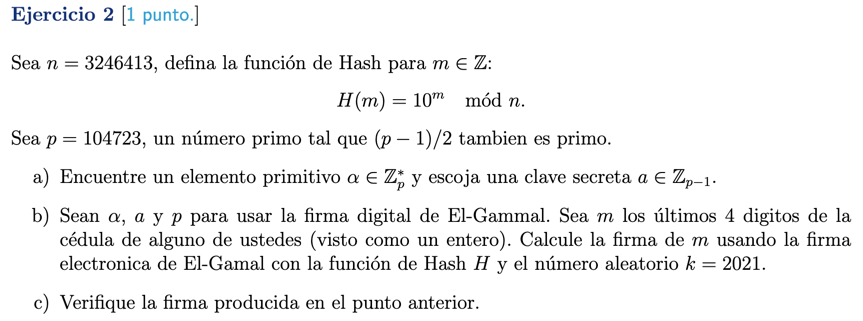

# Ejercicio 3

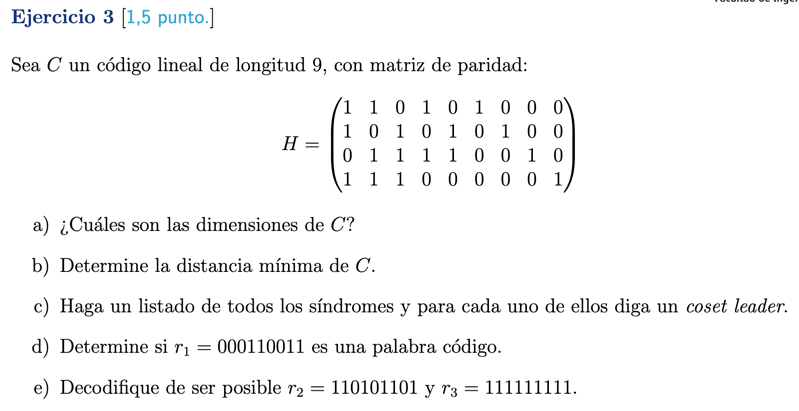

# Ejercicio 4

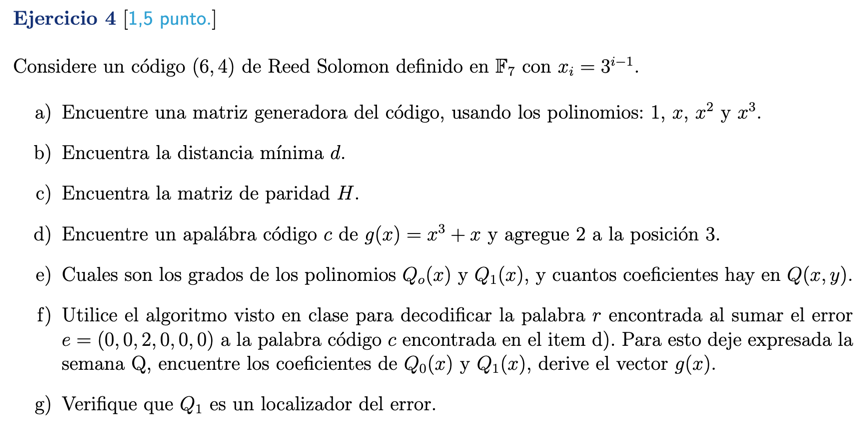